# Laboratorio 1 — Series de Tiempo
## Análisis Exploratorio de Datos (EDA)
**Curso:** CC3084 – Data Science | Universidad del Valle de Guatemala
**Dataset:** Base_Migracion_2009-2026jun.xlsx — Ingreso de viajeros internacionales a Guatemala (enero 2009 – junio 2026)
**Integrantes** Daniela Ramírez de León 23053

## 1. Configuración e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

RAW_XLSX = Path("Base_Migracion_2009-2026jun.xlsx")
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
RAW_CSV = DATA_DIR / "base_migracion_2009_2026jun.csv"


## 2. Carga de datos

In [2]:
if RAW_CSV.exists():
    df = pd.read_csv(RAW_CSV)
    print(f"Datos cargados desde CSV: {RAW_CSV}")
else:
    df = pd.read_excel(RAW_XLSX, sheet_name="Datos")
    df.to_csv(RAW_CSV, index=False, encoding="utf-8")
    print(f"Datos cargados desde Excel y convertidos a CSV: {RAW_CSV}")

print("Dimensiones:", df.shape)
df.head()


Datos cargados desde CSV: data\base_migracion_2009_2026jun.csv
Dimensiones: (161036, 13)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [3]:
# Notas / metadatos originales de la fuente (hoja "Notas" del Excel)
notas = pd.read_excel(RAW_XLSX, sheet_name="Notas", header=None)
for _, row in notas.dropna(how="all").iterrows():
    titulo, contenido = row[0], row[1]
    if pd.notna(contenido):
        print(f"* {titulo}: {contenido}\n")
    elif pd.notna(titulo):
        print(f"{titulo}\n")


Notas — Base 2009 a junio 2026

* Origen y estatus: Ingreso de viajeros internacionales a Guatemala. USO EXCLUSIVAMENTE ACADÉMICO; no son cifras oficiales. Tres tramos de fuente: 2009-2020 respaldos históricos; 2021-2022 entrega del IGM (jul-2026) con caracterización; 2023-jun 2026 sistema depurado de conteos del INGUAT.

* Cobertura: Enero 2009 a junio 2026: 210 meses consecutivos, sin huecos. 161,036 registros.

* Estructura: Formato largo: una fila por combinación de mes, vía, frontera, país/agrupación y tipo de viajero, con la cantidad en 'Viajero' (medida). Categorías de tipo independientes; sin filas de total ni doble conteo.

* Tipo de Viajero: Turista: pernocta al menos una noche. Excursionista: visita sin pernoctar (mismo día). Viajero: cruza frontera sin calificar como visitante (trabajo fronterizo, tránsito, carga, tripulación, comercio de alta frecuencia); NO se contabiliza como visitante. Cruceristas: pasajeros de crucero (solo hasta 2022; desde 2023 los cruceros se miden 

**Lectura de los metadatos de la fuente:**
- El dataset integra datos de tres fuentes (2009–2020, 2021–2022 y 2023–jun 2026), por lo que la metodología de recolección cambia entre períodos.
- Formato largo: cada fila representa una combinación única de (mes, vía, frontera, país/agrupación y tipo de viajero), donde Viajero indica la cantidad registrada.
- Desde 2023, País cambia de países individuales a agrupaciones de mercado, por lo que las comparaciones de categorías antes y después de ese año requieren precaución.
- Desde 2023, Tipo de Viajero excluye viajeros no turísticos frecuentes, por lo que para comparar series históricas se recomienda usar Turista + Excursionista.
Los Cruceristas solo están incluidos hasta 2022; desde 2023 se registran en una fuente externa, generando una discontinuidad en esa categoría.

## 3. Vista general del dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Año,161036.0,NaN,NaN,NaN,2016.017543,4.552887,2009.0,2012.0,2016.0,2019.0,2026.0
Mes cod,161036.0,NaN,NaN,NaN,6.416075,3.531936,1.0,3.0,6.0,10.0,12.0
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Diccionario de datos**:

| Columna | Descripción |
|---|---|
| `Año` | Año de ingreso al país |
| `Mes cod` | Codificación numérica del mes (1-12) |
| `Mes` | Nombre del mes |
| `Vía` | Vía de entrada: Aérea, Terrestre, Marítima |
| `Frontera` | Frontera / puesto de ingreso específico |
| `País` | País de residencia (hasta 2023); agrupación de mercado (desde 2023) |
| `Región` | Clasificación usada para reportes nacionales |
| `Región dos` | Agrupación de `Región` en continentes / grandes áreas |
| `Regiones OMT` | Subregión según la Organización Mundial del Turismo |
| `MCEO` | Mercado o agrupación comercial estratégica |
| `Agrupación Residencia` | Región de residencia agregada |
| `Tipo de Viajero` | Turista, Excursionista, Viajero, Cruceristas |
| `Viajero` | Cantidad de viajeros (variable de interés) |


## 4. Limpieza de nombres de columnas

Renombramos las columnas a minúsculas / `snake_case` sin tildes para facilitar el trabajo en código, manteniendo un diccionario de vuelta a los nombres originales para las tablas/gráficos finales.

In [6]:
rename_map = {
    "Año": "anio",
    "Mes cod": "mes_cod",
    "Mes": "mes",
    "Vía": "via",
    "Frontera": "frontera",
    "País": "pais",
    "Región": "region",
    "Región dos": "region_dos",
    "Regiones OMT": "region_omt",
    "MCEO": "mceo",
    "Agrupación Residencia": "agrupacion_residencia",
    "Tipo de Viajero": "tipo_viajero",
    "Viajero": "viajeros",
}
df = df.rename(columns=rename_map)

# Fecha (primer día del mes) para graficar la serie de tiempo
df["fecha"] = pd.to_datetime(dict(year=df["anio"], month=df["mes_cod"], day=1))

df.head()


,anio,mes_cod,mes,via,frontera,pais,region,region_dos,region_omt,mceo,agrupacion_residencia,tipo_viajero,viajeros,fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


## 5. Valores faltantes

In [7]:
faltantes = df.isna().sum().to_frame("n_faltantes")
faltantes["pct_faltantes"] = (faltantes["n_faltantes"] / len(df) * 100).round(3)
faltantes.sort_values("n_faltantes", ascending=False)


,n_faltantes,pct_faltantes
anio,0,0.0
mes_cod,0,0.0
mes,0,0.0
via,0,0.0
frontera,0,0.0
pais,0,0.0
region,0,0.0
region_dos,0,0.0
region_omt,0,0.0
mceo,0,0.0


**Interpretación:** el dataset no presenta valores nulos (NaN) en ninguna columna: la fuente ya entrega los datos completos y sin huecos temporales (210 meses consecutivos, enero 2009 a junio 2026, según la hoja de Notas). Sin embargo, esto no significa que no haya valores "faltantes" disfrazados, más abajo revisamos categorías como "region_dos == "0"", que probablemente representan datos sin clasificar.

## 6. Duplicados

In [8]:
dup_exactos = df.duplicated().sum()
print(f"Filas 100% duplicadas (todas las columnas): {dup_exactos}")

# Duplicados "semánticos": misma combinación de llave categórica con más de un registro
llave = ["anio", "mes_cod", "via", "frontera", "pais", "tipo_viajero"]
dup_llave = df.duplicated(subset=llave).sum()
print(f"Combinaciones repetidas de {llave}: {dup_llave}")


Filas 100% duplicadas (todas las columnas): 0
Combinaciones repetidas de ['anio', 'mes_cod', 'via', 'frontera', 'pais', 'tipo_viajero']: 22


**Interpretación:** no hay filas completamente duplicadas ni combinaciones repetidas de la llave categórica (año, mes, vía, frontera, país, tipo de viajero). 

## 7. Consistencia de categorías

Revisamos los valores únicos de las variables categóricas para detectar inconsistencias de captura.

In [9]:
cat_cols = ["mes", "via", "frontera", "region", "region_dos", "region_omt", "mceo", "agrupacion_residencia", "tipo_viajero"]
resumen_cat = pd.DataFrame({
    "n_categorias": [df[c].nunique() for c in cat_cols],
}, index=cat_cols)
resumen_cat["pais_n_categorias"] = None
resumen_cat.loc["pais_n_categorias"] = None
print("Número de categorías por variable:")
resumen_cat


Número de categorías por variable:


,n_categorias,pais_n_categorias
mes,12.0,None
via,3.0,None
frontera,22.0,None
region,17.0,None
region_dos,11.0,None
region_omt,26.0,None
mceo,8.0,None
agrupacion_residencia,33.0,None
tipo_viajero,4.0,None
pais_n_categorias,NaN,NaN


In [10]:
print("Vía:", sorted(df['via'].unique()))
print()
print("Tipo de viajero:", sorted(df['tipo_viajero'].unique()))
print()
print("Región dos:", sorted(df['region_dos'].unique()))
print()
print(f"País: {df['pais'].nunique()} categorías distintas")
print(f"Frontera: {df['frontera'].nunique()} categorías distintas ->", sorted(df['frontera'].unique()))


Vía: ['Aérea', 'Marítima', 'Terrestre']

Tipo de viajero: ['Cruceristas', 'Excursionista', 'Turista', 'Viajero']

Región dos: ['0', 'América Del Centro', 'América Del Norte', 'América Del Sur y el Caribe', 'Asia', 'Cruceristas', 'Cruceros', 'Europa', 'Oceanía', 'Oriente Medio', 'Otros Paises Del Mundo']

País: 235 categorías distintas
Frontera: 22 categorías distintas -> ['01 La Aurora', '02 Mundo Maya', '03 Puerto Quetzal', '04 Santo Tomás de Castilla', '05 Puerto Barrios', '06 Livingston', '07 Valle Nuevo', '08 Pedro de Alvarado', '09 San Cristóbal', '10 La Ermita (Nueva Anguiatú)', '11 Agua Caliente', '12 El Florido', '13 El Cinchado / El Corinto', '14 Tecún Umán', '15 El Carmen', '16 La Mesilla', '17 El Naranjo', '18 Bethel', '19 Gracias a Dios', '20 Melchor de Mencos', '22 Otra frontera', 'Cruceros']


**Hallazgos de calidad de datos a tener en cuenta más adelante:**
- region_dos contiene la categoría "0" en 13 registros de 2022 (821 viajeros en total, 0.002% del total), correspondientes a "Islas Vírgenes Americanas" y "República Democrática del Congo": esos dos países no quedaron mapeados a ninguna región en el catálogo de ese año. Se trata como "Otros/Sin clasificar" en el análisis por región (sección 13).
- Existen dos categorías para cruceros ("Cruceristas" y "Cruceros"), por lo que conviene unificarlas.
- La estructura de pais cambia desde 2023 (país individual a agrupación de mercado), lo que limita comparaciones históricas por país.
- Las variables via y tipo_viajero son consistentes y no presentan problemas de categorización.

## 8. Valores atípicos (outliers)

In [11]:
df["viajeros"].describe()


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: viajeros, dtype: float64

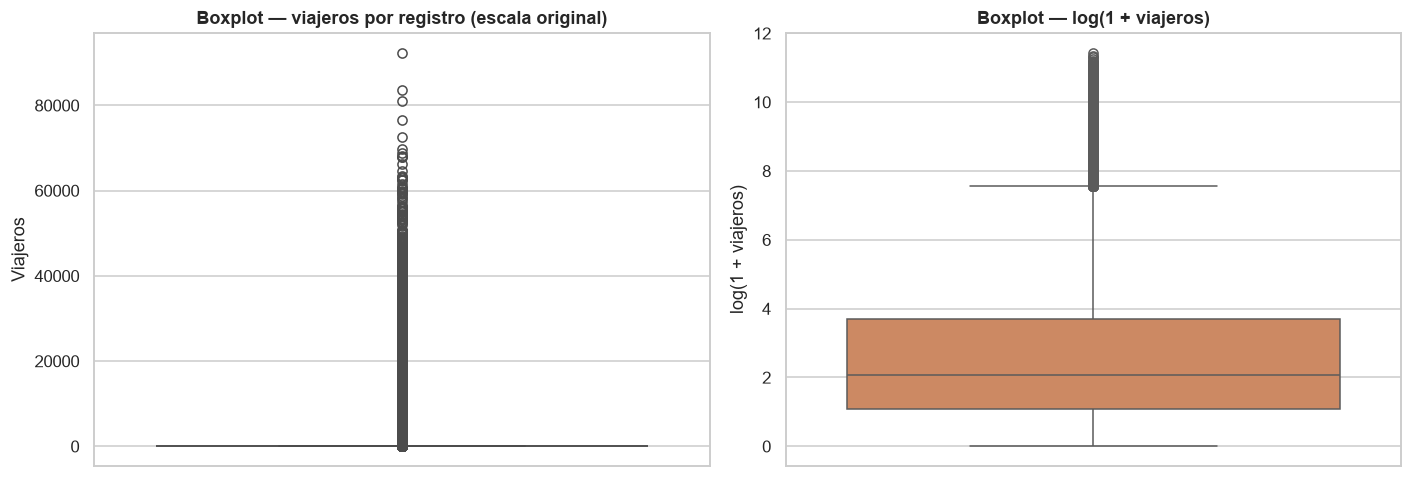

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(y=df["viajeros"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Boxplot — viajeros por registro (escala original)")
axes[0].set_ylabel("Viajeros")

sns.boxplot(y=np.log1p(df["viajeros"]), ax=axes[1], color="#DD8452")
axes[1].set_title("Boxplot — log(1 + viajeros)")
axes[1].set_ylabel("log(1 + viajeros)")

plt.tight_layout()
plt.show()


In [13]:
q1, q3 = df["viajeros"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
n_outliers = (df["viajeros"] > lim_sup).sum()
pct_outliers = n_outliers / len(df) * 100

print(f"Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}  límite superior (Q3+1.5*IQR)={lim_sup:.1f}")
print(f"Registros por encima del límite superior: {n_outliers} ({pct_outliers:.1f}% del total)")
print(f"Registros con viajeros <= 0: {(df['viajeros'] <= 0).sum()}")
print(f"Viajero no es un valor entero en {(df['viajeros'] % 1 != 0).sum()} registros (ej.: {df.loc[df['viajeros'] % 1 != 0, 'viajeros'].head(3).tolist()})")


Q1=2.0  Q3=38.9  IQR=36.9  límite superior (Q3+1.5*IQR)=94.2
Registros por encima del límite superior: 26390 (16.4% del total)
Registros con viajeros <= 0: 54
Viajero no es un valor entero en 50847 registros (ej.: [6518.968580415471, 6051.031419584529, 4.656521739130435])


**Interpretación:** La variable viajeros presenta un fuerte sesgo a la derecha: la mayoría de registros tienen valores bajos y unos pocos concentran volúmenes muy altos, por lo que los valores atípicos son esperados y no representan errores.
Existen valores decimales debido a estimaciones o ajustes de la fuente, por lo que conviene tratar viajeros como una variable continua.
En el análisis de series de tiempo, estos outliers por fila se atenúan al agregar los datos por mes; la atención debe centrarse en outliers temporales reales, como la caída de 2020 por la pandemia.

## 9. Estadísticas descriptivas

In [14]:
print("Estadísticas descriptivas de 'viajeros' por tipo de viajero:\n")
df.groupby("tipo_viajero")["viajeros"].describe().round(1)


Estadísticas descriptivas de 'viajeros' por tipo de viajero:



,count,mean,std,min,25%,50%,75%,max
tipo_viajero,,,,,,,,
Cruceristas,204.0,5413.7,4225.8,85.0,2094.0,4454.9,7173.5,21680.9
Excursionista,19730.0,459.7,1833.7,0.0,2.0,10.0,80.3,38463.0
Turista,117912.0,319.2,2611.3,0.0,2.0,6.0,33.0,83511.0
Viajero,23190.0,192.8,1281.2,0.0,2.0,8.2,44.0,92336.0


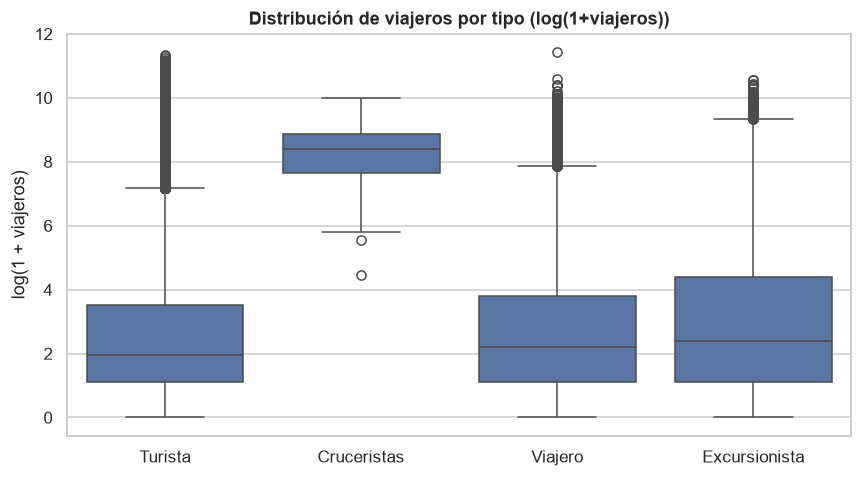

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="tipo_viajero", y=np.log1p(df["viajeros"]), ax=ax)
ax.set_title("Distribución de viajeros por tipo (log(1+viajeros))")
ax.set_xlabel("")
ax.set_ylabel("log(1 + viajeros)")
plt.tight_layout()
plt.show()


**Interpretación:** Turista registra el mayor volumen mediano por registro, seguido de Excursionista. En cambio, Cruceristas y Viajero presentan volúmenes menores y más concentrados.

## 10. Comportamiento temporal del número de viajeros

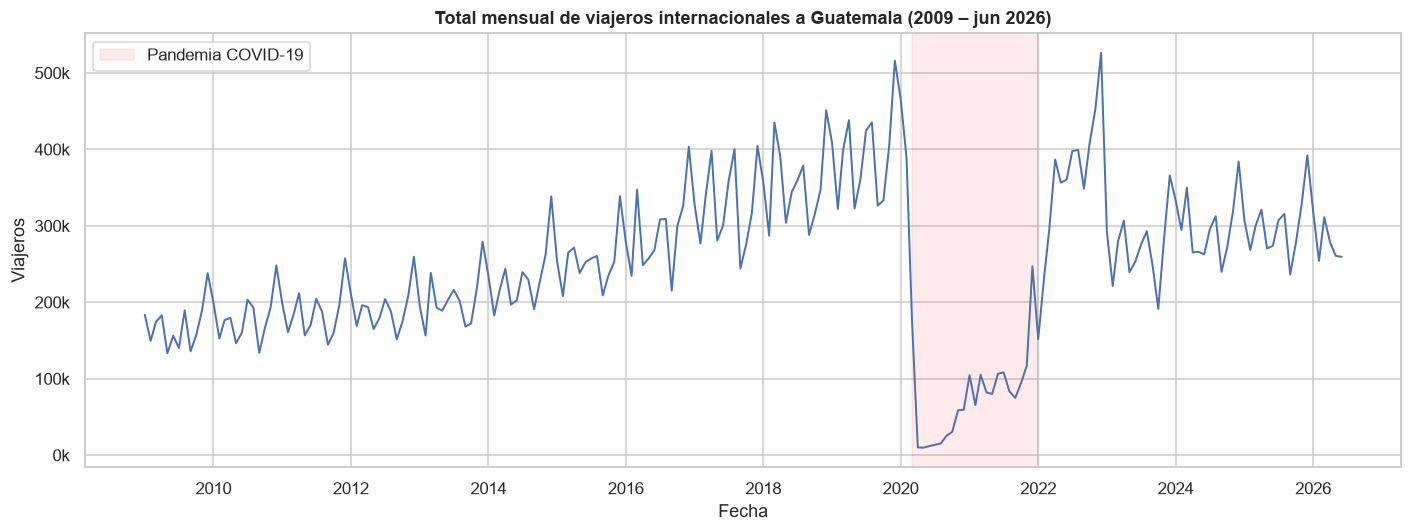

In [16]:
serie_mensual = df.groupby("fecha", as_index=False)["viajeros"].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_mensual["fecha"], serie_mensual["viajeros"], color="#4C72B0", linewidth=1.3)
ax.set_title("Total mensual de viajeros internacionales a Guatemala (2009 – jun 2026)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f}k"))
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.08, label="Pandemia COVID-19")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


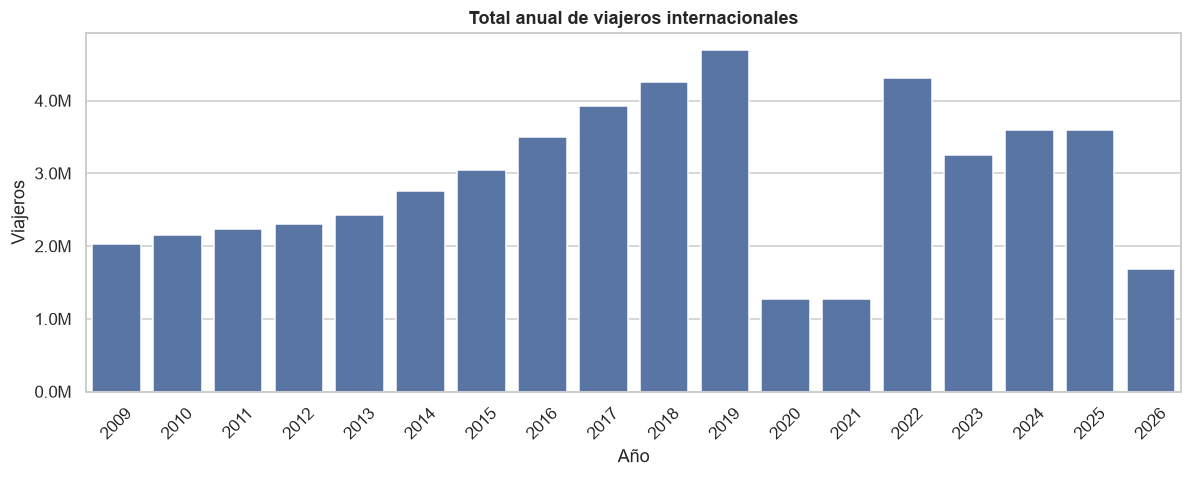

In [17]:
serie_anual = df.groupby("anio", as_index=False)["viajeros"].sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=serie_anual, x="anio", y="viajeros", color="#4C72B0", ax=ax)
ax.set_title("Total anual de viajeros internacionales")
ax.set_xlabel("Año")
ax.set_ylabel("Viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretación:**
- La serie presenta una tendencia creciente entre 2009 y 2019, con un patrón estacional recurrente.
- En 2020 ocurre una caída drástica por la pandemia de COVID-19, con una recuperación gradual desde finales de 2021 y niveles cercanos a los previos en 2022.
- La disminución observada desde 2023 responde principalmente a un cambio metodológico en la definición de Viajero, no a una reducción real del turismo.
- La serie no es estacionaria, ya que presenta tendencia, estacionalidad y quiebres estructurales (pandemia y cambio metodológico).

## 11. Efecto de la pandemia (COVID-19) en detalle

Total 2019 (pre-pandemia): 4,691,820
Total 2020: 1,266,340  (73.0% vs 2019)
Total 2021: 1,267,768  (73.0% vs 2019)
Total 2022 (recuperación): 4,316,164  (-8.0% vs 2019)


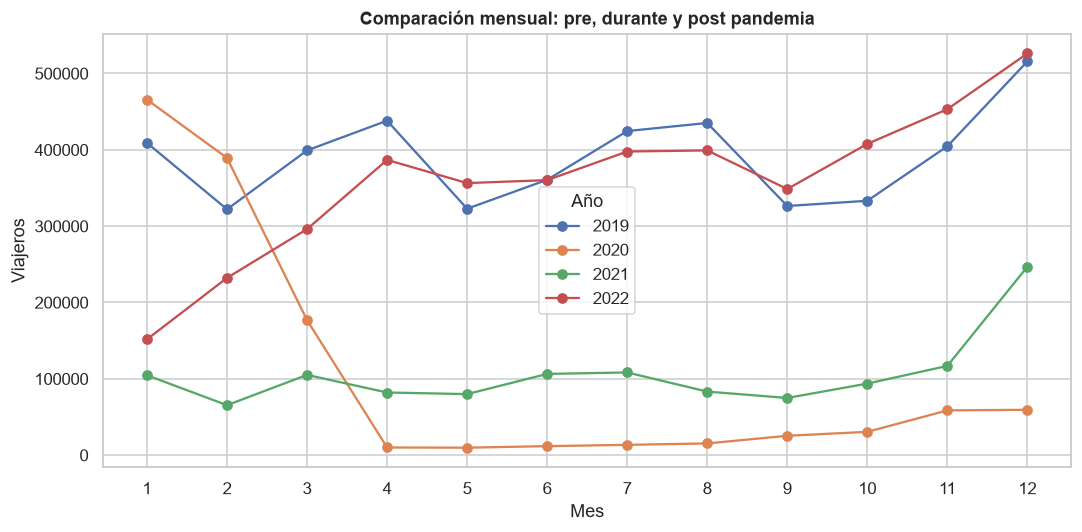

In [18]:
pre = df[df["anio"] == 2019]["viajeros"].sum()
pandemia = df[df["anio"].isin([2020, 2021])]["viajeros"].sum()
post = df[df["anio"] == 2022]["viajeros"].sum()

print(f"Total 2019 (pre-pandemia): {pre:,.0f}")
print(f"Total 2020: {df[df['anio']==2020]['viajeros'].sum():,.0f}  ({(1 - df[df['anio']==2020]['viajeros'].sum()/pre)*100:.1f}% vs 2019)")
print(f"Total 2021: {df[df['anio']==2021]['viajeros'].sum():,.0f}  ({(1 - df[df['anio']==2021]['viajeros'].sum()/pre)*100:.1f}% vs 2019)")
print(f"Total 2022 (recuperación): {post:,.0f}  ({(post/pre - 1)*100:+.1f}% vs 2019)")

comparacion = df[df["anio"].isin([2019, 2020, 2021, 2022])].groupby(["anio", "mes_cod"], as_index=False)["viajeros"].sum()
comparacion_pivot = comparacion.pivot(index="mes_cod", columns="anio", values="viajeros")

fig, ax = plt.subplots(figsize=(10, 5))
for anio in [2019, 2020, 2021, 2022]:
    ax.plot(comparacion_pivot.index, comparacion_pivot[anio], marker="o", label=str(anio))
ax.set_title("Comparación mensual: pre, durante y post pandemia")
ax.set_xlabel("Mes")
ax.set_ylabel("Viajeros")
ax.set_xticks(range(1, 13))
ax.legend(title="Año")
plt.tight_layout()
plt.show()


**Interpretación:** La serie registra una caída de hasta 97% interanual en 2020 por el cierre de fronteras, manteniéndose en niveles bajos durante 2021. La recuperación ocurre en 2022, cuando los valores vuelven a igualar o superar los de 2019.

## 12. Países con mayor cantidad de viajeros

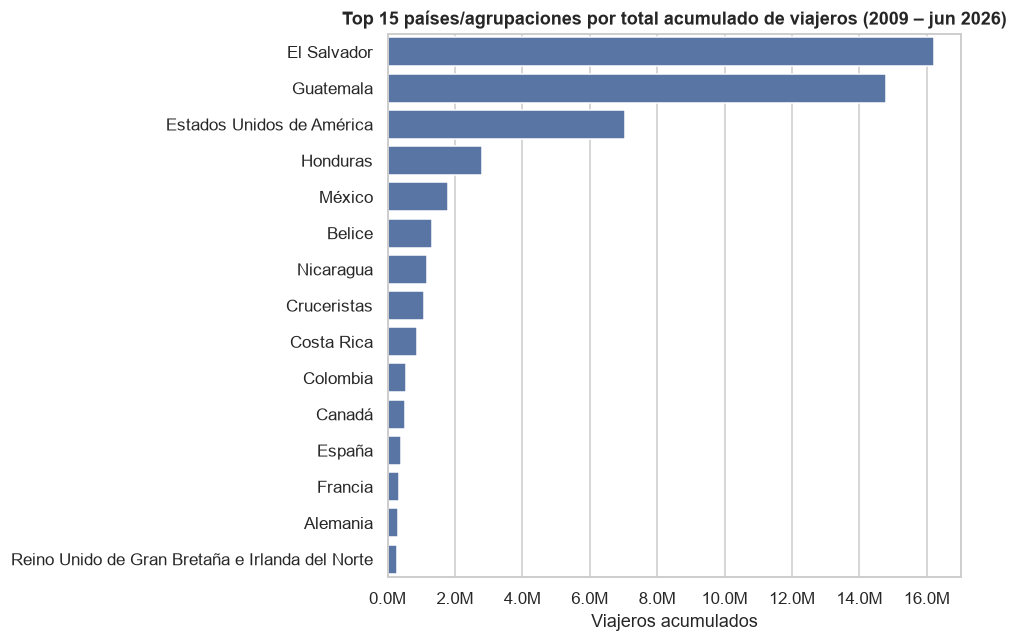

,pais,viajeros
60,El Salvador,1.621398e+07
86,Guatemala,1.479233e+07
67,Estados Unidos de América,7.047843e+06
93,Honduras,2.788233e+06
145,México,1.808946e+06
20,Belice,1.328256e+06
150,Nicaragua,1.164343e+06
50,Cruceristas,1.078372e+06
48,Costa Rica,8.821797e+05
45,Colombia,5.610353e+05


In [19]:
top_paises = df.groupby("pais", as_index=False)["viajeros"].sum().sort_values("viajeros", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_paises, y="pais", x="viajeros", color="#4C72B0", ax=ax)
ax.set_title("Top 15 países/agrupaciones por total acumulado de viajeros (2009 – jun 2026)")
ax.set_xlabel("Viajeros acumulados")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.tight_layout()
plt.show()

top_paises


**Interpretación:** El Salvador, Guatemala y Estados Unidos concentran la mayor cantidad de viajeros, seguidos por Honduras y México, lo que refleja el predominio del flujo terrestre centroamericano. La categoría Cruceristas aparece como un artefacto de la fuente y no corresponde a un país real.

## 13. Regiones con mayor cantidad de viajeros

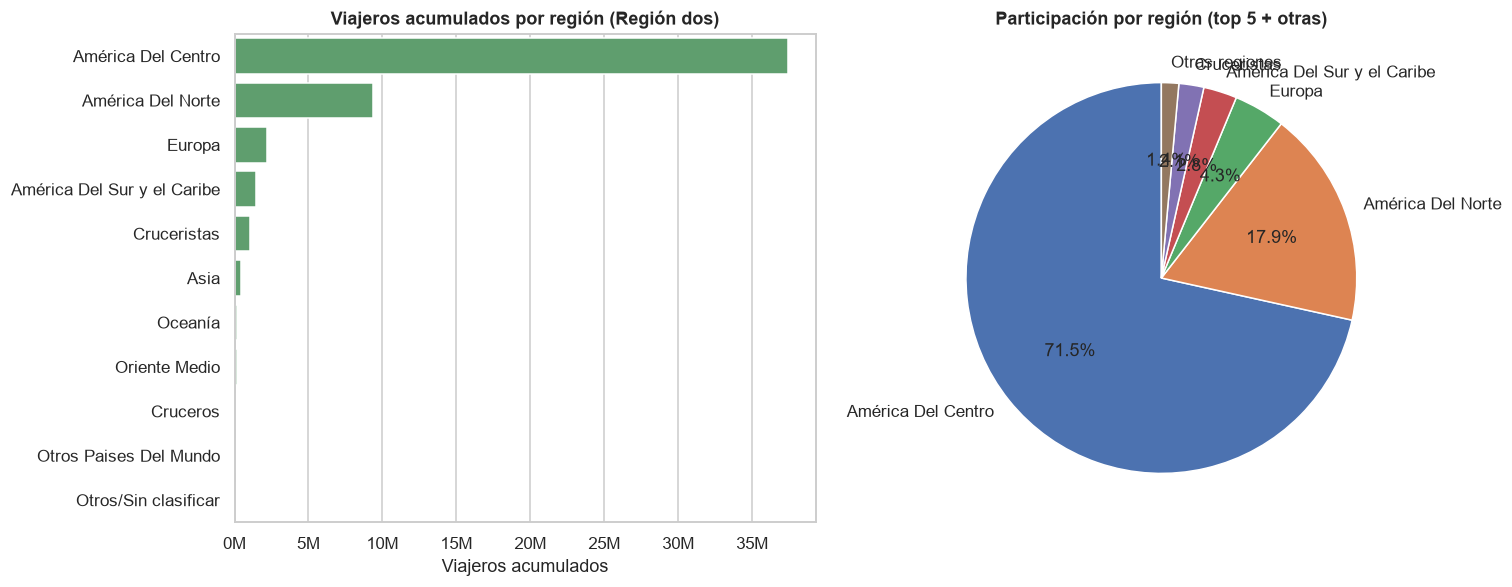

In [20]:
df["region_dos"] = df["region_dos"].replace("0", "Otros/Sin clasificar")

top_regiones = df.groupby("region_dos", as_index=False)["viajeros"].sum().sort_values("viajeros", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.barplot(data=top_regiones, y="region_dos", x="viajeros", color="#55A868", ax=axes[0])
axes[0].set_title("Viajeros acumulados por región (Región dos)")
axes[0].set_xlabel("Viajeros acumulados")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f}M"))

top5_regiones = top_regiones.head(5).copy()
otros = top_regiones["viajeros"].iloc[5:].sum()
top5_regiones.loc[len(top5_regiones)] = ["Otras regiones", otros]
axes[1].pie(top5_regiones["viajeros"], labels=top5_regiones["region_dos"], autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("deep"))
axes[1].set_title("Participación por región (top 5 + otras)")

plt.tight_layout()
plt.show()


**Interpretación:** América del Centro concentra la mayor parte de los viajeros (73%), seguida por América del Norte (18%) y Europa (4%). Esto evidencia el predominio del movimiento intrarregional centroamericano sobre el turismo de larga distancia. La categoría "Otros/Sin clasificar" (antes "0", ver sección 7) aporta un volumen insignificante y no altera esta conclusión.

## 14. Vías de ingreso y fronteras más utilizadas

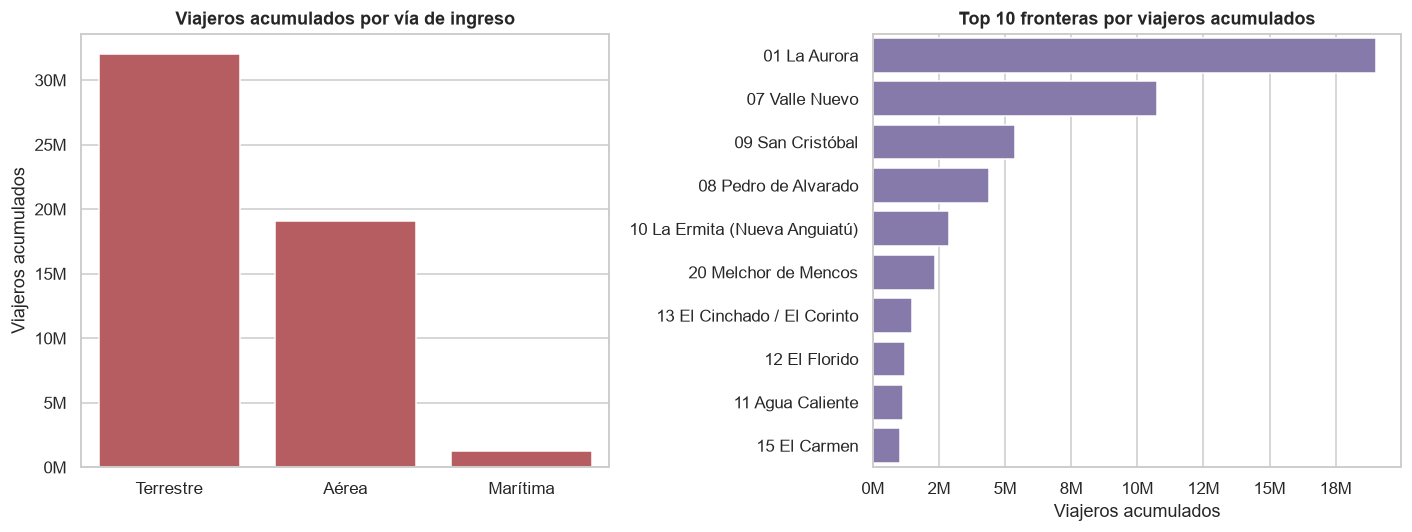

,via,viajeros
2,Terrestre,3.199530e+07
0,Aérea,1.906385e+07
1,Marítima,1.228782e+06


In [21]:
via_totales = df.groupby("via", as_index=False)["viajeros"].sum().sort_values("viajeros", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=via_totales, x="via", y="viajeros", color="#C44E52", ax=axes[0])
axes[0].set_title("Viajeros acumulados por vía de ingreso")
axes[0].set_ylabel("Viajeros acumulados")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f}M"))

top_fronteras = df.groupby("frontera", as_index=False)["viajeros"].sum().sort_values("viajeros", ascending=False).head(10)
sns.barplot(data=top_fronteras, y="frontera", x="viajeros", color="#8172B2", ax=axes[1])
axes[1].set_title("Top 10 fronteras por viajeros acumulados")
axes[1].set_xlabel("Viajeros acumulados")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f}M"))

plt.tight_layout()
plt.show()

via_totales


**Interpretación:** La vía terrestre concentra la mayor parte de los viajeros (60%), seguida por la aérea (36%) y la marítima (2%). Entre las fronteras, La Aurora es el principal punto de ingreso, mientras que Valle Nuevo, San Cristóbal y Pedro de Alvarado destacan entre los pasos terrestres, confirmando que la frontera con El Salvador es el corredor de mayor tráfico del país.

## 15. Tipo de viajero

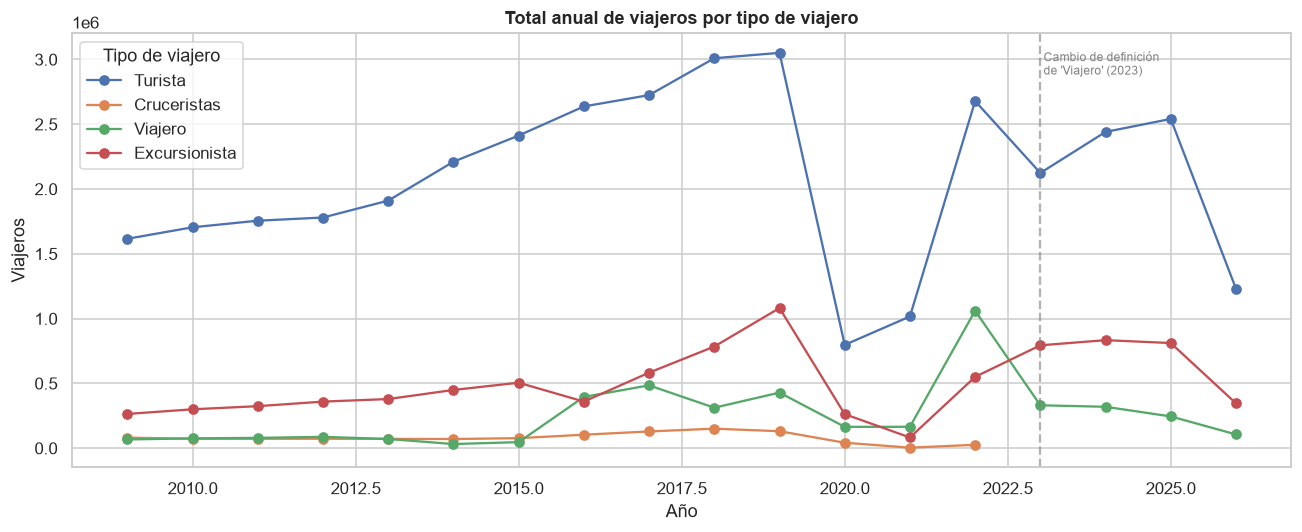

In [22]:
tipo_anual = df.groupby(["anio", "tipo_viajero"], as_index=False)["viajeros"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
for tipo in df["tipo_viajero"].unique():
    sub = tipo_anual[tipo_anual["tipo_viajero"] == tipo]
    ax.plot(sub["anio"], sub["viajeros"], marker="o", label=tipo)
ax.set_title("Total anual de viajeros por tipo de viajero")
ax.set_xlabel("Año")
ax.set_ylabel("Viajeros")
ax.axvline(2023, color="gray", linestyle="--", alpha=0.6)
ax.text(2023.05, ax.get_ylim()[1]*0.9, "Cambio de definición\nde 'Viajero' (2023)", fontsize=8, color="gray")
ax.legend(title="Tipo de viajero")
plt.tight_layout()
plt.show()


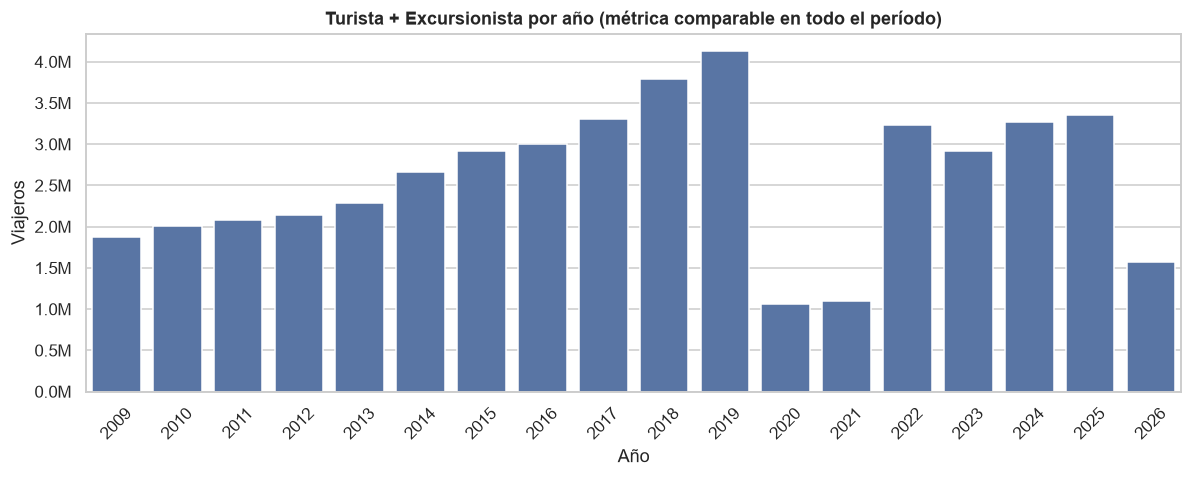

In [23]:
df["turista_excursionista"] = df["tipo_viajero"].isin(["Turista", "Excursionista"])
serie_consistente = (
    df[df["turista_excursionista"]]
    .groupby("anio", as_index=False)["viajeros"].sum()
    .rename(columns={"viajeros": "turista_mas_excursionista"})
)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=serie_consistente, x="anio", y="turista_mas_excursionista", color="#4C72B0", ax=ax)
ax.set_title("Turista + Excursionista por año (métrica comparable en todo el período)")
ax.set_xlabel("Año")
ax.set_ylabel("Viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretación:** Turista es la categoría predominante durante todo el período. La categoría Viajero disminuye desde 2023 debido a un cambio metodológico, mientras que Cruceristas desaparece del dataset a partir de ese año por un cambio en la fuente de datos. La serie Turista + Excursionista ofrece la comparación más consistente, mostrando crecimiento hasta 2019, caída por la pandemia en 2020–2021 y recuperación desde 2022.